# Model to transform infrastructure

- enables to transform the methane into a hydrogen network
- allows for new investments on defined edges
- bidirectional net flows on edges possible

### Import packages

In [754]:
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import networkx as nx
import os
from collections import Counter

In [755]:
# Define a function to convert the solution to a DataFrame
def solution_to_dataframe(commodities, edges, solution, String):
    # Create an empty list to store the data
    data = []
    
    # Iterate over commodities and edges to populate the data list
    for h in commodities:
        for i, j in edges:
            if solution[h, i, j] > 0:
                data.append({'Commodity': h, 'Source': i, 'Destination': j, String: solution[h, i, j]})
    
    # Convert the data list to a DataFrame
    df = pd.DataFrame(data)
    
    # Return the DataFrame
    return df

def conversion_solution_to_dataframe(commodities, edges, solution):
    # Create an empty list to store the data
    data = []
    
    # Iterate over commodities and edges to populate the data list
    for h in commodities:
        for i, j in edges:
            # Append the data to the list as a dictionary
            data.append({
                'Commodity': h,
                'Source': i,
                'Destination': j,
                'Conversion': solution[h, i, j]
            })
    
    # Convert the data list to a DataFrame
    df = pd.DataFrame(data)
    
    # Return the DataFrame
    return df

### Model run definitions

In [756]:
#use shortage nodes to avoid infeasibilities
model_with_shortage = False #True or False

#should the code print the results in the notebook?
print_results = True #True or False

### Import data

In [757]:
# Specify the path to your Excel file
input_file_path = os.path.join('..', '..','01_data', '01_input_data', '02_processed')
# excel_file_path = '\Data_full_network.xlsx'  
excel_file_path = '\dummy_data_example_network.xlsx'

input_file_path  = input_file_path + excel_file_path
full_input_path = os.path.abspath(os.path.join(os.getcwd(), input_file_path))

output_file_path = os.path.join('..', '..', '01_data', '02_output_data', '01_bidirectional_results')
output_file_name = '\\flow_and_network_data.xlsx'
output_path_file =  output_file_path + output_file_name
full_output_path_file = os.path.abspath(os.path.join(os.getcwd(), output_path_file))

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\mar.eco\AppData\Local\Temp\ipykernel_9288\1818271163.py:4: SyntaxWarning: invalid escape sequence '\d'
  excel_file_path = '\dummy_data_example_network.xlsx'


In [758]:
# Read the Excel file into a DataFrame
df_nodes = pd.read_excel(full_input_path, sheet_name='Nodes')
df_commodities = pd.read_excel(full_input_path, sheet_name='Commodities')
df_edges = pd.read_excel(full_input_path, sheet_name='Edges')
df_parameter = pd.read_excel(full_input_path, sheet_name='Parameters')
df_supply_values = pd.read_excel(full_input_path, sheet_name='Supply')

### Create input data structure

In [759]:
#commodities
commodities = df_commodities['Commodities'].tolist()

#nodes
nodes = df_nodes['Nodes'].tolist()

#edges
edges_base = list(zip(df_edges['Source'], df_edges['Destination']))

#initial capacities
capacity_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['initial_capacities'] 
                 for _, row in df_parameter.iterrows()}

#maximal capacities
capacity_limit_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['max_capacities'] 
                 for _, row in df_parameter.iterrows()}

#variable transportation cost
cost_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['costs_edge'] 
                 for _, row in df_parameter.iterrows()}

#investment cost new capacity
investment_cost_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['new_build_cost'] 
                 for _, row in df_parameter.iterrows()}

#investment cost convert capacity
conversion_cost_base = {tuple(row[['Commodity', 'Source', 'Destination']]): row['conversion_cost'] 
                 for _, row in df_parameter.iterrows()}

#converseion capacity factor
conversion_capacity_factor = {tuple(row[['Commodity', 'Source', 'Destination']]): row['conversion_capacity_factor'] 
                 for _, row in df_parameter.iterrows()}

#demand and supply
inflow = {tuple(row[['Commodity', 'Node']]): row['Supply'] 
                 for _, row in df_supply_values.iterrows()}

In [760]:
nodes_with_supply = [node for (_, node), val in inflow.items() if val > 0]

# One dump node per supply node
nodes_excess = [f"{n}_excess" for n in nodes_with_supply]

# Directed dump edge
edges_excess = list(zip(nodes_with_supply, nodes_excess))

# Add the new dump nodes to global list of nodes 
nodes = list(set(nodes) | set(nodes_excess))

# dump arcs are added to edges_base
edges_base += edges_excess
edges_base = list(dict.fromkeys(edges_base)) # to drop duplicates

In [761]:
HIGH_PENALTY = 1_000.0            # discourage dumping, but keep model feasible

for c in commodities:
    for u, v in edges_excess:
        key = (c, u, v)
        capacity_base[key]       = 1e9
        capacity_limit_base[key] = 1e9
        cost_base[key]           = HIGH_PENALTY
        investment_cost_base[key] = 0.0
        conversion_cost_base[key] = 0.0
        conversion_capacity_factor[key] = 1.0


# Same for nodes ensure zero inflow for dumb nodes
for c in commodities:
    for n_excess in nodes_excess:
        key = (c, n_excess)
        if key not in inflow:
            inflow[key] = 0.0

### adjust input data

In [762]:
#create node types for different model configurations
if model_with_shortage == True:
    #create shortage nodes
    supply_nodes = []
    for (commodity, node), value in inflow.items():
        if value > 0:
            supply_nodes.append(node)
    unique_supply_nodes = list(set(supply_nodes))
    # Add '_shortage' to each element in the list
    unique_supply_nodes_shortage = [node + '_shortage' for node in unique_supply_nodes]
    nodes_shortage = unique_supply_nodes_shortage
    #create new edges for all shortage nodes to the actual node with high-capacity
    # Create a new list by zipping the two lists
    edges_shortage = list(zip(unique_supply_nodes_shortage, unique_supply_nodes))
    # Create a new data structure using the result_list and commodities
    edge_shortage_cap = {}

    for (commodity, suffix, original) in [(c, s, o) for c in commodities for s, o in zip(unique_supply_nodes_shortage, unique_supply_nodes)]:
        edge_shortage_cap[(commodity, suffix, original)] = 10000000

    nodes_network = nodes #+ nodes_shortage
else:
    nodes_network = nodes

In [763]:
# Reverse edges
edges_reverse = [(destination, source) for source, destination in edges_base  if (source, destination) not in edges_excess]

# Combined edges
edges = edges_base + edges_reverse

# Reverse cap
capacity_reverse = {(k, j, i): cap for (k, i, j), cap in capacity_base.items()}

capacity = {**capacity_base, **capacity_reverse}

# Reverse cap
capacity_limit_reverse = {(k, j, i): cap for (k, i, j), cap in capacity_limit_base.items()}

capacity_limit = {**capacity_limit_base, **capacity_limit_reverse}

# Reverse cost
cost_reverse = {(k, j, i): cost for (k, i, j), cost in cost_base.items()}

cost = {**cost_base, **cost_reverse}

# Reverse cost
investment_cost_reverse = {(k, j, i): cost for (k, i, j), cost in investment_cost_base.items()}

investment_cost = {**investment_cost_base, **investment_cost_reverse}

# Reverse cost
conversion_cost_reverse = {(k, j, i): cost for (k, i, j), cost in conversion_cost_base.items()}

conversion_cost = {**conversion_cost_base, **conversion_cost_reverse}


### Network control

In [764]:
#check in all nodes are connected via edges

G = nx.Graph()
G.add_edges_from(edges_base)

# Check if the graph is connected
if nx.is_connected(G):
    print("The graph is connected.")
else:
    print("The graph is not connected.")

The graph is connected.


In [765]:
# Check if all nodes are connected
if set(nodes) in nx.connected_components(G):
    print("All nodes are connected.")
else:
    print("Not all nodes are connected.")

All nodes are connected.


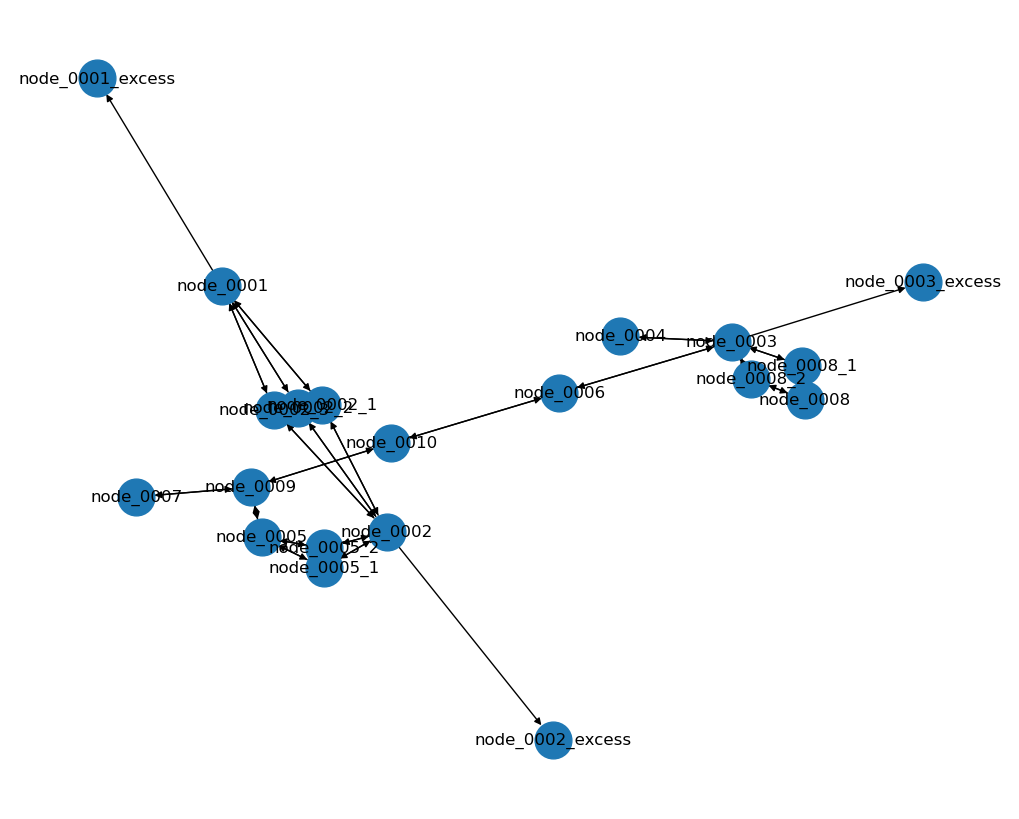

In [766]:
import matplotlib.pyplot as plt

G = nx.DiGraph()
for i, j in edges:  
    G.add_edge(i, j)

plt.figure(figsize=(10,8))
nx.draw(G, with_labels=True, node_size=700)
plt.show()


In [767]:
if len(edges) != len(set(edges)):
    print("There are duplicates in the list of tuples.")

    # Count occurrences of each edge
    edge_count = Counter(edges)

    # Find duplicates
    duplicates = [edge for edge, count in edge_count.items() if count > 1]
    #print duplicated edges if they exist
    for dup in duplicates:
        print(dup)
else:
    print("No duplicates found in the list of tuples.")

No duplicates found in the list of tuples.


## Model

### Create model

In [768]:
# Create optimization model
m = gp.Model("Grid_Transformation")

### Define variables

In [769]:
# defin two different edge sets 
edges_phys      = edges_base                    # physical arcs
edges_phys_all  = edges_phys + [
    (j, i) for (i, j) in edges_phys if (i, j) not in edges_excess
]                                               # add reverse of physical arcs

# Flow travels everywhere
edges_flow = edges_phys_all + edges_excess

# But the ivestment and capacity are only on physical ones
edges_capital = edges_phys_all

# Avoid duplicates here as well 
edges       = list(dict.fromkeys(edges))
edges_flow  = list(dict.fromkeys(edges_flow))
edges_capital = list(dict.fromkeys(edges_capital))

In [770]:
'''# Create variables
if model_with_shortage == True: 
    flow = m.addVars(commodities, edges+edges_shortage, vtype=GRB.CONTINUOUS, name="flow")
else:
    flow = m.addVars(commodities, edges, vtype=GRB.CONTINUOUS, name="flow")'''

edges_total = edges_flow + edges_shortage if model_with_shortage else edges_flow

flow = m.addVars(commodities, edges_total, vtype=GRB.CONTINUOUS, name="flow")

# Change edges to edges_capital to have physical ones only 
# variable for capacity investment
investment = m.addVars(commodities, edges_capital, vtype=GRB.CONTINUOUS, name="investment")

# Variable for converted capacity
converted_capacity = m.addVars(commodities, edges_capital, vtype=GRB.CONTINUOUS, name="converted_capacity")

# Binary variable to indicate if conversion is active
conversion_indicator = m.addVars(commodities, edges_capital, vtype=GRB.BINARY, name="conversion_indicator")

### Define objective

In [771]:
# Set objective function
m.setObjective(
    gp.quicksum(flow[h, i, j] * cost[h, i, j] for h in commodities for i, j in edges) +
    gp.quicksum(investment[h, i, j] * investment_cost[h, i, j] for h in commodities for i, j in edges_base) +
    gp.quicksum(converted_capacity[h, i, j] * conversion_cost[h, j, i] for h in commodities for i, j in edges_base),
    GRB.MINIMIZE
)

### Define constraints

In [772]:
'''# Edge-capacity constraints with investment
m.addConstrs((flow[h, i, j] <= converted_capacity[h, i, j] + investment[h, i, j] for h in commodities for i, j in edges), "cap")

# Edge-capacity total limit
m.addConstrs((investment[h, i, j] + converted_capacity[h, i, j] 
              <= capacity_limit[h, i, j] for h in commodities for i, j in edges_base), "cap")

# Investment constraints
m.addConstrs((investment[h, i, j] == investment[h, j, i] for h in commodities for i, j in edges), "conversion")

#conversion binary constraint
m.addConstrs((gp.quicksum(conversion_indicator[h, i, j] for h in commodities) == 1 for i, j in edges), "conversion_indicator_sum_one")

#link the converted capacity to the initial capacity
m.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[h, i, j] 
              == converted_capacity[h, i, j] for h in commodities[1:] for i, j in edges), "capacity_relationship")
m.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[commodities[0], i, j]
        == converted_capacity[commodities[0], i, j]
        for i, j in edges), "capacity_relationship_first_commodity")

# Conversion constraints
m.addConstrs((converted_capacity[h, i, j] == converted_capacity[h, j, i] for h in commodities for i, j in edges), "conversion")

# balanced node flows: Kirchhoff's 1st law
m.addConstrs(
    (
        flow.sum(h, "*", j) + inflow[h, j] == flow.sum(h, j, "*")
        for h in commodities
        for j in nodes_network
    ),
    "node",
)

# Flow-conservation constraints
if model_with_shortage == True: 
    m.addConstrs(
        (
            flow.sum(h, "*", j) - flow.sum(h, j, "*") <= 0
            for h in commodities
            for j in nodes_shortage
        ),
        "node",
    )

    # Edge-capacity constraints between shortage nodes and network nodes
    m.addConstrs((flow[h, i, j] <= edge_shortage_cap[h, i, j] for h in commodities for i, j in edges_shortage), "cap")

print('Constraints createt')'''

'# Edge-capacity constraints with investment\nm.addConstrs((flow[h, i, j] <= converted_capacity[h, i, j] + investment[h, i, j] for h in commodities for i, j in edges), "cap")\n\n# Edge-capacity total limit\nm.addConstrs((investment[h, i, j] + converted_capacity[h, i, j] \n              <= capacity_limit[h, i, j] for h in commodities for i, j in edges_base), "cap")\n\n# Investment constraints\nm.addConstrs((investment[h, i, j] == investment[h, j, i] for h in commodities for i, j in edges), "conversion")\n\n#conversion binary constraint\nm.addConstrs((gp.quicksum(conversion_indicator[h, i, j] for h in commodities) == 1 for i, j in edges), "conversion_indicator_sum_one")\n\n#link the converted capacity to the initial capacity\nm.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[h, i, j] \n              == converted_capacity[h, i, j] for h in commodities[1:] for i, j in edges), "capacity_relationship")\nm.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[com

In [773]:
# Edge-capacity constraints with investment
m.addConstrs((flow[h, i, j] <= converted_capacity[h, i, j] + investment[h, i, j] for h in commodities for i, j in edges_capital), "cap")

# Edge-capacity total limit
m.addConstrs((investment[h, i, j] + converted_capacity[h, i, j] 
              <= capacity_limit[h, i, j] for h in commodities for i, j in edges_base), "cap")

# Investment constraints
m.addConstrs((investment[h, i, j] == investment[h, j, i] for h in commodities for i, j in edges_capital if (j, i) in edges_capital), "conversion")

#conversion binary constraint
m.addConstrs((gp.quicksum(conversion_indicator[h, i, j] for h in commodities) == 1 for i, j in edges_capital), "conversion_indicator_sum_one")

#link the converted capacity to the initial capacity
m.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[h, i, j] 
              == converted_capacity[h, i, j] for h in commodities[1:] for i, j in edges_capital), "capacity_relationship")
m.addConstrs((capacity[commodities[0], i, j] * conversion_indicator[commodities[0], i, j]
        == converted_capacity[commodities[0], i, j]
        for i, j in edges_capital), "capacity_relationship_first_commodity")

# Conversion constraints
m.addConstrs((converted_capacity[h, i, j] == converted_capacity[h, j, i] for h in commodities for i, j in edges_capital if (j, i) in edges_capital), "conversion")

# balanced node flows: Kirchhoff's 1st law
m.addConstrs(
    (
        flow.sum(h, "*", j) + inflow[h, j] == flow.sum(h, j, "*")
        for h in commodities
        for j in nodes_network
    ),
    "node",
)

# Flow-conservation constraints
if model_with_shortage == True: 
    m.addConstrs(
        (
            flow.sum(h, "*", j) - flow.sum(h, j, "*") <= 0
            for h in commodities
            for j in nodes_shortage
        ),
        "node",
    )

    # Edge-capacity constraints between shortage nodes and network nodes
    m.addConstrs((flow[h, i, j] <= edge_shortage_cap[h, i, j] for h in commodities for i, j in edges_shortage), "cap")

print('Constraints createt')

Constraints createt


### Optimize the model

In [774]:
# Compute optimal solution
# m.feasRelaxS(0, False, False, True) # To see which constraints are failing
m.optimize()

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 5 PRO 3500U w/ Radeon Vega Mobile Gfx, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 461 rows, 344 columns and 1100 nonzeros
Model fingerprint: 0x4f0a0fc0
Variable types: 258 continuous, 86 integer (86 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+09]
  Objective range  [5e-01, 1e+03]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 341 rows and 254 columns
Presolve time: 0.02s

Explored 0 nodes (0 simplex iterations) in 0.05 seconds (0.00 work units)
Thread count was 1 (of 8 available processors)

Solution count 0

Model is infeasible
Best objective -, best bound -, gap -


In [775]:
for constr in m.getConstrs():
    name = constr.ConstrName
    if name.startswith("node["):
        rhs = constr.RHS
        if rhs < 0:
            print(f"{name} → {rhs}")
        elif rhs > 0:
            print(f"{name} → {rhs}")
        else:
            print(f"{name} → 0")

node[Methane,node_0010] → 6.0
node[Methane,node_0002_3] → 0
node[Methane,node_0001] → -15.0
node[Methane,node_0009] → 7.0
node[Methane,node_0003_excess] → 0
node[Methane,node_0002_excess] → 0
node[Methane,node_0002] → 2.0
node[Methane,node_0008_2] → 0
node[Methane,node_0007] → 3.0
node[Methane,node_0004] → 5.0
node[Methane,node_0005_1] → 0
node[Methane,node_0005_2] → 0
node[Methane,node_0008_1] → 0
node[Methane,node_0005] → 6.0
node[Methane,node_0003] → -20.0
node[Methane,node_0006] → 1.0
node[Methane,node_0008] → 5.0
node[Methane,node_0002_2] → 0
node[Methane,node_0001_excess] → 0
node[Methane,node_0002_1] → 0
node[Hydrogen,node_0010] → 0
node[Hydrogen,node_0002_3] → 0
node[Hydrogen,node_0001] → 1.0
node[Hydrogen,node_0009] → 3.0
node[Hydrogen,node_0003_excess] → 0
node[Hydrogen,node_0002_excess] → 0
node[Hydrogen,node_0002] → -10.0
node[Hydrogen,node_0008_2] → 0
node[Hydrogen,node_0007] → 0
node[Hydrogen,node_0004] → 0
node[Hydrogen,node_0005_1] → 0
node[Hydrogen,node_0005_2] → 0
nod

In [776]:
m.computeIIS()

for c in m.getConstrs():
    if c.IISConstr:
        print(f"Infeasible cstr: {c.ConstrName} → rhs: {c.RHS}")

for v in m.getVars():
    if v.IISLB:
        print(f"Infeasible lower bound: {v.VarName} ≥ {v.LB}")
    if v.IISUB:
        print(f"Infeasible upper bound: {v.VarName} ≤ {v.UB}")

Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 11.0 (22631.2))

CPU model: AMD Ryzen 5 PRO 3500U w/ Radeon Vega Mobile Gfx, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads


Computing Irreducible Inconsistent Subsystem (IIS)...

           Constraints          |            Bounds           |  Runtime
      Min       Max     Guess   |   Min       Max     Guess   |
--------------------------------------------------------------------------
        0       461         -         0       258         -           0s
        8         8         8         1         1         1           0s

IIS computed: 8 constraints, 1 bounds
IIS runtime: 0.06 seconds (0.00 work units)
Infeasible cstr: cap[Methane,node_0003,node_0006] → rhs: 0.0
Infeasible cstr: cap[Methane,node_0003,node_0006] → rhs: 6.329656656031141
Infeasible cstr: node[Methane,node_0003_excess] → rhs: 0.0
Infeasible cstr: node[Methane,node_0008_2] → rhs: 0.0
In

## Outputs

In [777]:
if m.Status == GRB.OPTIMAL:
    solution = m.getAttr("X", flow)
    investment_solution = m.getAttr("X", investment)
    converted_capacity_solution = m.getAttr("X", converted_capacity)
    conversion_indicator_solution = m.getAttr("X", conversion_indicator)

    print("****************************")
    print(f"Total cost: {m.objVal}")
    print("****************************")

    if print_results == True:
    
        for h in commodities:
            print(f"\nOptimal flows for {h}:")
            for i, j in edges:
                if solution[h, i, j] > 0:
                    print(f"{i} -> {j}: {solution[h, i, j]:g}")
    
            if model_with_shortage == True:
                for i, j in edges_shortage:
                    if solution[h, i, j] > 0:
                        print(f"{i} -> {j}: {solution[h, i, j]:g}")
    
            print(f"\nOptimal investments for {h}:")
            for i, j in edges_base:
                if investment_solution[h, i, j] > 0:
                    print(f"Investment for {h} in edge ({i} -> {j}): {investment_solution[h, i, j]:g}")
    
            print(f"\nOptimal converted capacities for {h}:")
            for i, j in edges_base:
                if converted_capacity_solution[h, i, j] > 0:
                    print(f"Converted capacity for {h} from {i} to {j}: {converted_capacity_solution[h, i, j]:g}")
    
        print("\nOptimal conversion indicators:")
        for h in commodities:
            for i, j in edges_base:
                #
                    print(f"Conversion of {h} from {i} to {j} is: {conversion_indicator_solution[h, i, j]:g}")
else:
    print("No optimal solution found.")

No optimal solution found.


In [778]:
costs_df = pd.DataFrame({'Total Cost': [m.objVal]})
flows_df = solution_to_dataframe(commodities, edges, solution, 'Flow')
if model_with_shortage == True:
    flows_shortage_df = solution_to_dataframe(commodities, edges_shortage, solution, 'Flow')
investments_df = solution_to_dataframe(commodities, edges_base, investment_solution, 'Capacity_invested')
conversion_df = solution_to_dataframe(commodities, edges_base, converted_capacity_solution, 'Capacity_converted')
conversion_binaries_df = conversion_solution_to_dataframe(commodities, edges_base, conversion_indicator_solution)

AttributeError: Unable to retrieve attribute 'objVal'

In [ ]:
#create the ouput excel 
with pd.ExcelWriter(full_output_path_file) as writer:
    costs_df.to_excel(writer, sheet_name='network_costs', index=False) 
    flows_df.to_excel(writer, sheet_name='network_flows', index=False)
    if model_with_shortage == True:
            flows_shortage_df.to_excel(writer, sheet_name='network_shortage_flows', index=False)
    investments_df.to_excel(writer, sheet_name='Investment', index=False)
    conversion_df.to_excel(writer, sheet_name='Conversion', index=False)
    conversion_binaries_df.to_excel(writer, sheet_name='Conversion_binaries', index=False)    